# Deep Learning Assignment 2026 — Starting Code

## Loading Dataset

You can download the dataset from
https://www.kaggle.com/datasets/andrewmvd/lung-and-colon-cancer-histopathological-images

The Lung and Colon Cancer Histopathological Image Dataset (LC25000) consists of 25,000
histopathological images from 5 classes, with 5,000 images per class:

| Folder | Class |
| --- | --- |
| `colon_aca` | Colon adenocarcinoma |
| `colon_n` | Benign colonic tissue |
| `lung_aca` | Lung adenocarcinoma |
| `lung_n` | Benign lung tissue |
| `lung_scc` | Lung squamous cell carcinoma |

The cells below download the dataset, read all 25,000 images and resize them from
768 x 768 to **120 x 120**.

**Before you start:** Runtime -> Change runtime type -> **T4 GPU**. On a CPU runtime the
models in this assignment take many times longer to train.

### Step 1 — Download the dataset

`kagglehub` downloads the dataset and returns the path to it. You need a free Kaggle
account. If you are asked to authenticate, go to your Kaggle account page
(**Settings -> API -> Create New Token**), which downloads a `kaggle.json` file containing
your username and key, and enter those when prompted.

The first run downloads about 1.9 GB. Later runs reuse the cached copy.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andrewmvd/lung-and-colon-cancer-histopathological-images")

print("Path to dataset files:", path)

c:\Projects\Lung-and-Colon-Cancer-Classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\qian1\.cache\kagglehub\datasets\andrewmvd\lung-and-colon-cancer-histopathological-images\versions\1


### Step 2 — Check the folder structure

Run this before the loading step. If the paths are wrong you will see it here immediately,
rather than after 25,000 error messages.

In [2]:
import os

root = os.path.join(path, "lung_colon_image_set")

# root = "../data/lung_colon_image_set"

for r, dirs, fnames in os.walk(root):
    depth = r.replace(root, "").count(os.sep)
    print("  " * depth + os.path.basename(r) + f"  ({len(fnames)} files)")

lung_colon_image_set  (0 files)
  colon_image_sets  (0 files)
    colon_aca  (5000 files)
    colon_n  (5000 files)
  lung_image_sets  (0 files)
    lung_aca  (5000 files)
    lung_n  (5000 files)
    lung_scc  (5000 files)


### Step 3 — Load and resize the images

This takes a few minutes. Three things keep it as fast as possible:

* `Image.draft()` makes the JPEG decoder work at 192 x 192 instead of 768 x 768, skipping
  most of the decode cost before any resizing happens.
* A thread pool — PIL releases the GIL while decoding, so this actually parallelises.
* The output array is preallocated, so there is no build-a-list-then-copy step.

The result is cached to `/content`, so restarting the kernel does not cost you the whole
loop again.

The images are kept as `uint8` (values 0-255) on purpose: the full array is about 1.1 GB in
`uint8` but would be 4.3 GB as `float32`. Keras casts each batch to float automatically
during training, so you do not need to convert the whole array yourself.

In [3]:
from pathlib import Path

cwd = os.getcwd()
data_dir = os.path.abspath(os.path.join(cwd, os.pardir))
content_dir = Path(data_dir) / "data/content"

print(content_dir)

c:\Projects\Lung-and-Colon-Cancer-Classification\data\content


In [4]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm

# CACHE = "/content/lc25000_120.npz"
CACHE = Path(content_dir) / "lc25000_120.npz"
IMG_SIZE = (120, 120)

# Relative path of each class directory inside the dataset
class_dirs = {
    "colon_aca": "colon_image_sets/colon_aca",
    "colon_n":   "colon_image_sets/colon_n",
    "lung_aca":  "lung_image_sets/lung_aca",
    "lung_n":    "lung_image_sets/lung_n",
    "lung_scc":  "lung_image_sets/lung_scc",
}

if os.path.exists(CACHE):
    z = np.load(CACHE, allow_pickle=True)
    data, class_labels = z["data"], z["labels"]
    print("loaded from cache")
else:
    # Collect the file list first, so we can preallocate and parallelise
    files, labels = [], []
    for class_name, rel_path in class_dirs.items():
        class_path = os.path.join(root, rel_path)
        names = sorted(f for f in os.listdir(class_path)
                       if f.lower().endswith((".jpeg", ".jpg")))
        print(f"{class_name}: {len(names)} files")
        files += [os.path.join(class_path, n) for n in names]
        labels += [class_name] * len(names)

    data = np.zeros((len(files), *IMG_SIZE, 3), dtype=np.uint8)

    def load(i):
        with Image.open(files[i]) as image:
            image.draft("RGB", IMG_SIZE)     # decode at 192x192 instead of 768x768
            data[i] = np.asarray(image.convert("RGB").resize(IMG_SIZE, Image.LANCZOS))

    with ThreadPoolExecutor(max_workers=8) as ex:
        list(tqdm(ex.map(load, range(len(files))), total=len(files), desc="loading"))

    class_labels = np.array(labels)
    np.savez(CACHE, data=data, labels=class_labels)
    print("cached to", CACHE)

print(data.shape, data.dtype)
print(np.unique(class_labels, return_counts=True))

loaded from cache
(25000, 120, 120, 3) uint8
(array(['colon_aca', 'colon_n', 'lung_aca', 'lung_n', 'lung_scc'],
      dtype='<U9'), array([5000, 5000, 5000, 5000, 5000], dtype=int64))


### Optional — keep a copy on your Google Drive

The Colab disk is wiped when your runtime is deleted. Running this cell saves the arrays to
your Drive so you can reload them in a later session without repeating Steps 1-3.

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
#
# save_folder = "/content/drive/MyDrive/Deep_Learning_2026/Assignment/"
# os.makedirs(save_folder, exist_ok=True)
# np.save(save_folder + "data.npy", data)
# np.save(save_folder + "labels_name.npy", class_labels)
#
# # ...and to load them again in a later session:
# # data = np.load(save_folder + "data.npy")
# # class_labels = np.load(save_folder + "labels_name.npy")

---
## Preprocessing

Convert the target values using the proper function for one-hot encoding, and create
train, validation and test sets using stratified train-test splits with proportions of
60% / 20% / 20% and a random seed of 42.

In [5]:
RANDOM_SEED = 42

In [6]:
import tensorflow as tf

In [7]:
# Convert class names to the integer indices expected by one-hot.
class_index = {class_name: index for index, class_name in enumerate(class_dirs)}
class_indices = np.array([class_index[class_name] for class_name in class_labels])
len_classes = len(class_index)
labels = np.array(tf.one_hot(class_indices, depth=len_classes))

In [8]:
print(labels)

[[1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 ...
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]]


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    data, 
    labels, 
    test_size=0.4, 
    random_state=RANDOM_SEED, 
    stratify=labels
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, 
    y_temp, 
    test_size=0.5, 
    random_state=RANDOM_SEED, 
    stratify=y_temp
)

## Visualizing Sample Images

Randomly select 15 samples and display each image with its label as text on top of the
image, arranged in a single figure.

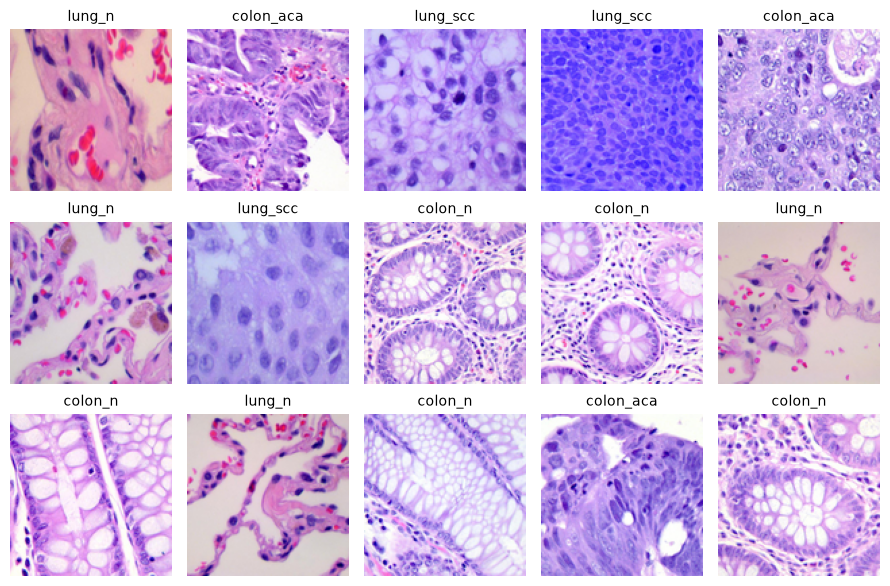

In [13]:
images_random = np.random.choice(len(data), size=15, replace=False)

fig, axes = plt.subplots(3, 5, figsize=(9, 6))
axes = axes.flatten()

for i, j in enumerate(images_random):
    img = data[j]
    label = class_labels[j]
    
    axes[i].imshow(img)
    axes[i].set_title(label, fontsize=10)
    axes[i].axis("off")
    
plt.tight_layout()
plt.show()

## Visualize Class Label Distribution

Create a bar plot showing how many samples the dataset has for each class.

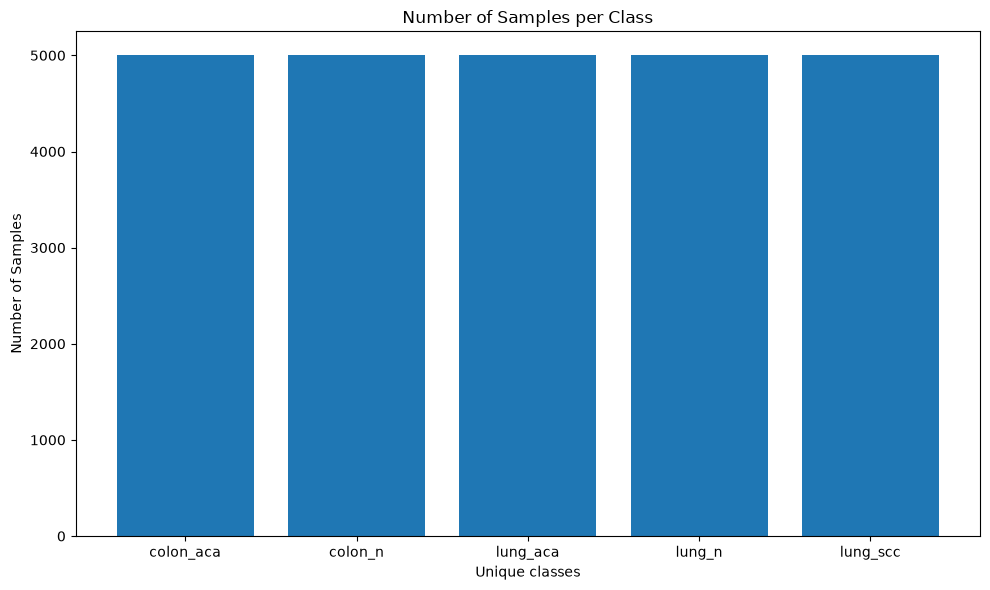

In [37]:
unique_classes, class_counts = np.unique(class_labels, return_counts=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(unique_classes, class_counts)

ax.set_title('Number of Samples per Class')
ax.set_xlabel('Unique classes')
ax.set_ylabel('Number of Samples')

ax.set_xticks(range(len(unique_classes)))
ax.set_xticklabels(unique_classes)

fig.tight_layout()
plt.show()

## Baseline Model

Implement the baseline CNN exactly as described in the assignment, train it for 15 epochs
with a batch size of 32, and analyse its performance (accuracy/loss curves, ROC curve with
AUC, confusion matrix, and performance measures for the validation and test sets).

In [10]:
from tensorflow.keras import models
from tensorflow.keras import layers

def build_baseline_model(input_shape=(120, 120, 3)):
    model = models.Sequential()
    model.add(layers.InputLayer(shape=input_shape))
    
    model.add(layers.Conv2D(32, kernel_size=(3, 3), padding="same", activation="relu"))
    model.add(layers.MaxPooling2D(2, 2))
    
    model.add(layers.Conv2D(64, kernel_size=(3, 3), padding="same", activation="relu"))
    model.add(layers.MaxPooling2D(2, 2))
    
    model.add(layers.Conv2D(64, kernel_size=(3, 3), padding="same", activation="relu"))
    model.add(layers.MaxPooling2D(2, 2))
    
    model.add(layers.Flatten())
    
    model.add(layers.Dense(64, activation="relu"))
    
    model.add(layers.Dense(5, activation="softmax"))
    
    model.compile(loss="categorical_crossentropy",
                  optimizer="adam",
                  metrics=['accuracy'])
   
    return model

In [11]:
baseline_model = build_baseline_model()
baseline_hist = baseline_model.fit(X_train,
                          y_train,
                          epochs=15, 
                          validation_data=(X_val, y_val),
                          batch_size=32,
                          verbose=0)

In [12]:
results_baseline = baseline_model.evaluate(X_test, y_test)

157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9488 - loss: 0.2853


In [40]:
def plot_history(data_list, label_list, title, y_label):
  ''' Plots a list of vectors.
  Parameters:
  data_list : list of vectors containing the values to plot
  label_list : list of labels describing the data, one per vector
  title : title of the plot
  ylabel : label for the y axis
  '''
  
  epochs = range(1, len(data_list[0]) + 1)
  fig, ax = plt.subplots(figsize=(10, 6))
  
  for data, label in zip(data_list, label_list):
    ax.plot(epochs, data, label=label)
    ax.set_title(title)
    ax.set_xlabel("Epochs")
    ax.set_ylabel(y_label)

  fig.legend(loc="lower right")
  fig.tight_layout()
  plt.show()

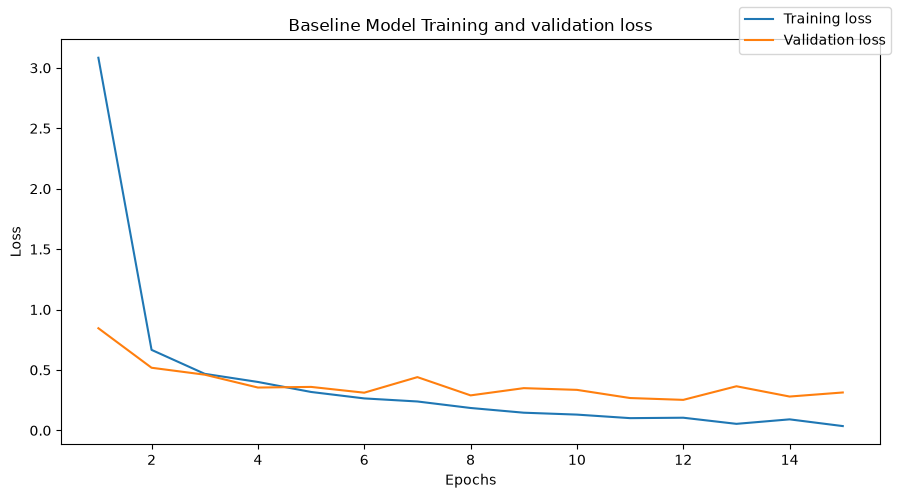

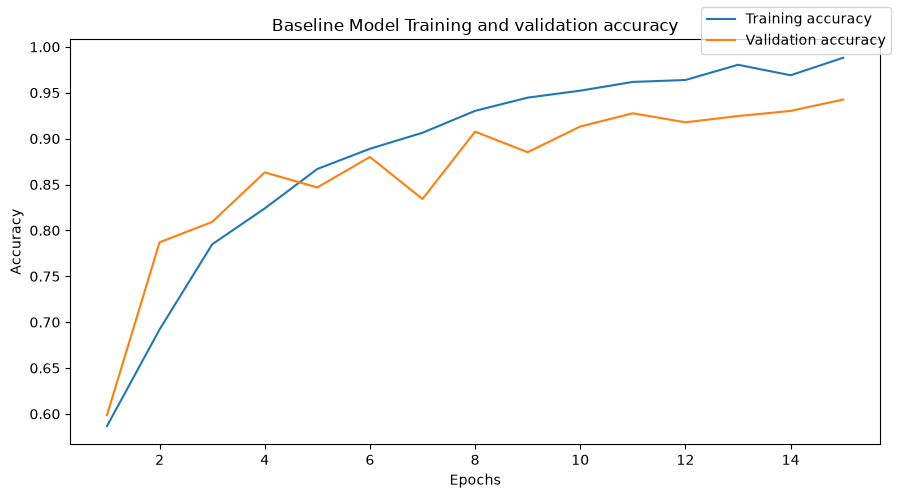

In [14]:
history_dict = baseline_hist.history
acc = history_dict["accuracy"]
loss = history_dict["loss"]
val_accuracy = history_dict["val_accuracy"]
val_loss = history_dict["val_loss"]


plot_history(data_list=[loss, val_loss],
             label_list=['Training loss', 'Validation loss'],
             title='Baseline Model Training and validation loss',
             y_label='Loss')

plot_history(data_list=[acc, val_accuracy],
             label_list=['Training accuracy', 'Validation accuracy'],
             title='Baseline Model Training and validation accuracy',
             y_label='Accuracy')

In [35]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

In [16]:
y_predict = baseline_model.predict(X_test)
y_predict_classes = np.argmax(y_predict, axis=1)

y_test_classes = np.argmax(y_test, axis=1)

print(classification_report(y_test_classes, y_predict_classes))

157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step
              precision    recall  f1-score   support

           0       0.96      0.95      0.96      1000
           1       0.97      0.96      0.96      1000
           2       0.90      0.92      0.91      1000
           3       0.97      0.99      0.98      1000
           4       0.94      0.92      0.93      1000

    accuracy                           0.95      5000
   macro avg       0.95      0.95      0.95      5000
weighted avg       0.95      0.95      0.95      5000



In [18]:
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 120, 120, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 60, 60, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       921,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,934,929 (11.20 MB)

 Trainable params: 978,309 (3.73 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,956,620 (7.46 MB)

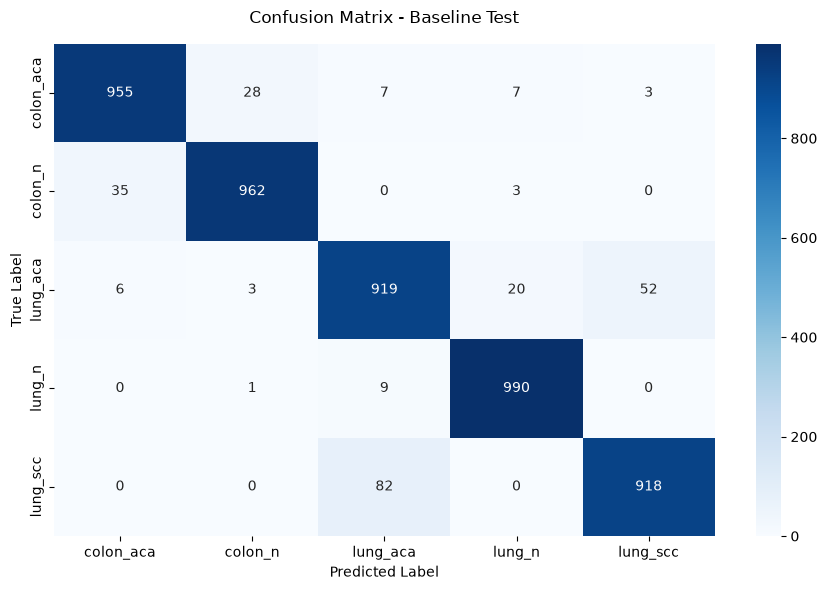

In [19]:
cm = confusion_matrix(y_test_classes, y_predict_classes)

# Use the same class order as the integer/one-hot label encoding.
class_names = list(class_index.keys())

plt.figure(figsize=(9, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title("Confusion Matrix - Baseline Test", pad=15)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

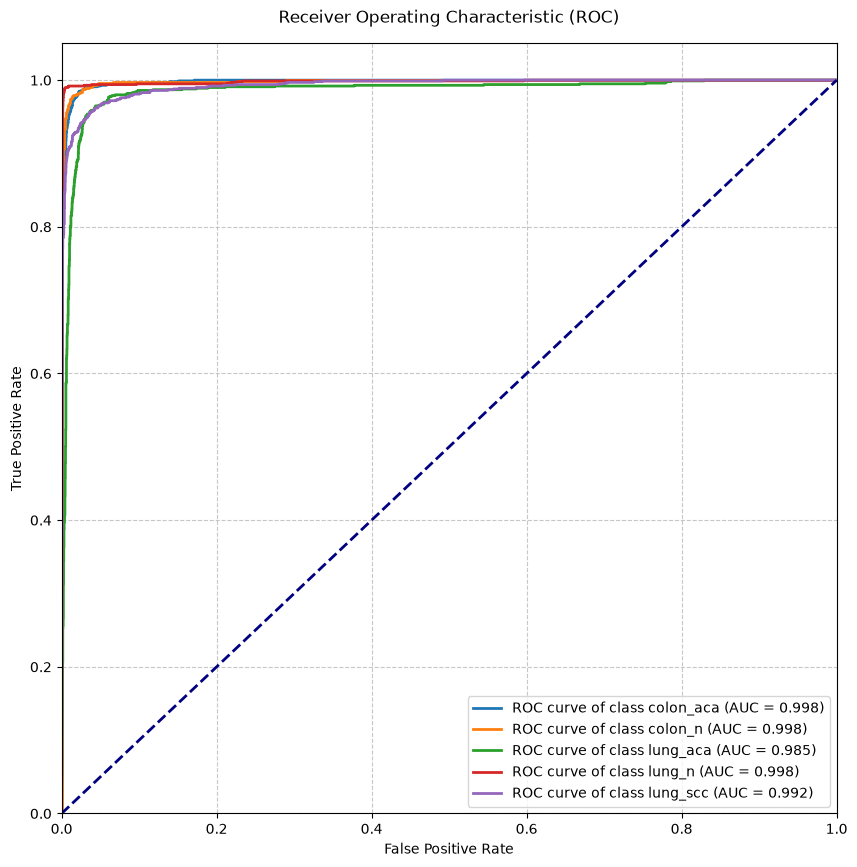

In [20]:
y_true_bin = label_binarize(y_test, classes=range(len_classes))

plt.figure(figsize=(10, 10))
for i in range(len_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_predict[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, 
              label=f'ROC curve of class {class_names[i]} (AUC = {roc_auc:.3f})')
    
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Receiver Operating Characteristic (ROC)', pad=15)
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Enhanced Model

Adapt the baseline by intentionally tweaking at least six different hyperparameters, and
compare the results against the baseline.

In [21]:
batch_size = 64

batch_64_model = build_baseline_model()

batch_64_hist = batch_64_model.fit(
    X_train, y_train,
    batch_size=batch_size,
    epochs=15,
    validation_data=(X_val, y_val),
    verbose=1)

Epoch 1/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 36s 150ms/step - accuracy: 0.6970 - loss: 4.2204 - val_accuracy: 0.8134 - val_loss: 0.4483
Epoch 2/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 34s 146ms/step - accuracy: 0.8421 - loss: 0.3678 - val_accuracy: 0.7976 - val_loss: 0.4165
Epoch 3/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 34s 146ms/step - accuracy: 0.8731 - loss: 0.3029 - val_accuracy: 0.8450 - val_loss: 0.3803
Epoch 4/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 34s 146ms/step - accuracy: 0.9082 - loss: 0.2322 - val_accuracy: 0.8988 - val_loss: 0.2687
Epoch 5/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 34s 146ms/step - accuracy: 0.9217 - loss: 0.1958 - val_accuracy: 0.8698 - val_loss: 0.3310
Epoch 6/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 34s 146ms/step - accuracy: 0.9495 - loss: 0.1321 - val_accuracy: 0.9284 - val_loss: 0.1914
Epoch 7/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 34s 146ms/step - accuracy: 0.9622 - loss: 0.0997 - val_accuracy: 0.9456 - val_loss: 0.1574
Epoch 8/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 34s 146ms/step - accuracy: 0.9570 - loss: 0

In [24]:
batch_size = 32
batch_32_model = build_baseline_model()
batch_32_hist = batch_32_model.fit(X_train,
                          y_train,
                          epochs=15, 
                          validation_data=(X_val, y_val),
                          batch_size=batch_size,
                          verbose=1)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 38s 78ms/step - accuracy: 0.4912 - loss: 3.4402 - val_accuracy: 0.6076 - val_loss: 0.9162
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 36s 77ms/step - accuracy: 0.5997 - loss: 0.8678 - val_accuracy: 0.5878 - val_loss: 0.8212
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 36s 76ms/step - accuracy: 0.6203 - loss: 0.7724 - val_accuracy: 0.5686 - val_loss: 0.7809
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 36s 76ms/step - accuracy: 0.6279 - loss: 0.7485 - val_accuracy: 0.5726 - val_loss: 0.7872
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 36s 76ms/step - accuracy: 0.7122 - loss: 0.5820 - val_accuracy: 0.7736 - val_loss: 0.5390
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 36s 77ms/step - accuracy: 0.8104 - loss: 0.4397 - val_accuracy: 0.8634 - val_loss: 0.3575
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 36s 77ms/step - accuracy: 0.8573 - loss: 0.3414 - val_accuracy: 0.8538 - val_loss: 0.3569
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 36s 77ms/step - accuracy: 0.9173 - loss: 0.2156 - 

In [25]:
batch_size = 16

batch_16_model = build_baseline_model()

batch_16_hist = batch_16_model.fit(
    X_train, y_train,
    batch_size=batch_size,
    epochs=15,
    validation_data=(X_val, y_val),
    verbose=1)

Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 40s 42ms/step - accuracy: 0.6209 - loss: 1.7982 - val_accuracy: 0.7528 - val_loss: 0.5601
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 38s 41ms/step - accuracy: 0.7662 - loss: 0.5159 - val_accuracy: 0.7902 - val_loss: 0.4899
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 39s 41ms/step - accuracy: 0.8109 - loss: 0.4293 - val_accuracy: 0.8410 - val_loss: 0.3938
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 39s 41ms/step - accuracy: 0.8698 - loss: 0.3209 - val_accuracy: 0.8900 - val_loss: 0.2916
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 39s 41ms/step - accuracy: 0.8963 - loss: 0.2659 - val_accuracy: 0.8890 - val_loss: 0.3029
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 39s 41ms/step - accuracy: 0.9167 - loss: 0.2226 - val_accuracy: 0.8794 - val_loss: 0.3561
Epoch 7/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 39s 41ms/step - accuracy: 0.9293 - loss: 0.1902 - val_accuracy: 0.8660 - val_loss: 0.4675
Epoch 8/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 39s 41ms/step - accuracy: 0.9357 - loss: 0.1708 - 

In [26]:
batch_size = 8

batch_8_model = build_baseline_model()

batch_8_hist = batch_8_model.fit(
    X_train, y_train,
    batch_size=batch_size,
    epochs=15,
    validation_data=(X_val, y_val),
    verbose=1)

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 47s 24ms/step - accuracy: 0.6765 - loss: 0.9652 - val_accuracy: 0.7810 - val_loss: 0.4869
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.7999 - loss: 0.4539 - val_accuracy: 0.8752 - val_loss: 0.3164
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.8547 - loss: 0.3612 - val_accuracy: 0.8488 - val_loss: 0.3949
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 23ms/step - accuracy: 0.8807 - loss: 0.3128 - val_accuracy: 0.8916 - val_loss: 0.3084
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.9143 - loss: 0.2217 - val_accuracy: 0.8626 - val_loss: 0.3951
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.9239 - loss: 0.2056 - val_accuracy: 0.9054 - val_loss: 0.2863
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 24ms/step - accuracy: 0.9247 - loss: 0.1959 - val_accuracy: 0.9328 - val_loss: 0.1971
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.9418 -

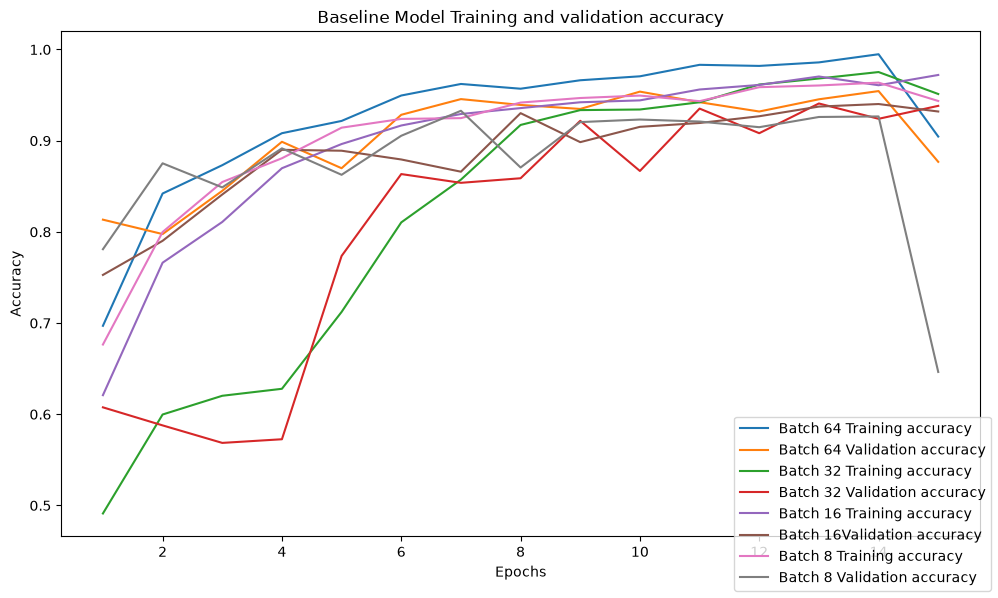

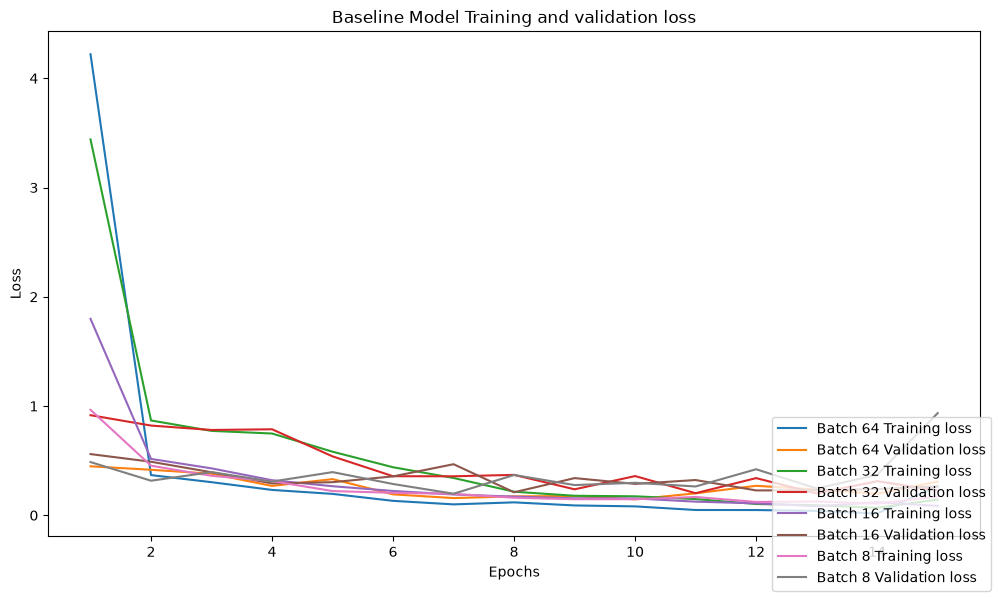

In [41]:
history_64_dict = batch_64_hist.history
acc64 = history_64_dict["accuracy"]
val_accuracy64 = history_64_dict["val_accuracy"]
loss64 = history_64_dict["loss"]
val_loss64 = history_64_dict["val_loss"]

history_32_dict = batch_32_hist.history
acc32 = history_32_dict["accuracy"]
val_accuracy32 = history_32_dict["val_accuracy"]
loss32 = history_32_dict["loss"]
val_loss32 = history_32_dict["val_loss"]

history_16_dict = batch_16_hist.history
acc16 = history_16_dict["accuracy"]  
val_accuracy16 = history_16_dict["val_accuracy"]
loss16 = history_16_dict["loss"]
val_loss16 = history_16_dict["val_loss"]

history_8_dict = batch_8_hist.history
acc8 = history_8_dict["accuracy"]   
val_accuracy8 = history_8_dict["val_accuracy"]
loss8 = history_8_dict["loss"]
val_loss8 = history_8_dict["val_loss"]

plot_history(data_list=[acc64, val_accuracy64, acc32, val_accuracy32, acc16, val_accuracy16, acc8, val_accuracy8],
            label_list=['Batch 64 Training accuracy', 'Batch 64 Validation accuracy',
                        'Batch 32 Training accuracy', 'Batch 32 Validation accuracy',
                        'Batch 16 Training accuracy', 'Batch 16Validation accuracy',
                        'Batch 8 Training accuracy', 'Batch 8 Validation accuracy'],
            title='Baseline Model Training and validation accuracy',
            y_label='Accuracy')

plot_history(data_list=[loss64, val_loss64, loss32, val_loss32, loss16, val_loss16, loss8, val_loss8],
            label_list=['Batch 64 Training loss', 'Batch 64 Validation loss',
                        'Batch 32 Training loss', 'Batch 32 Validation loss',
                        'Batch 16 Training loss', 'Batch 16 Validation loss',
                        'Batch 8 Training loss', 'Batch 8 Validation loss'],
            title='Baseline Model Training and validation loss',
            y_label='Loss')

In [ ]:
batch_size = 64

batch_64_model = build_baseline_model()

batch_64_hist = batch_64_model.fit(
    X_train, y_train,
    batch_size=batch_size,
    epochs=15,
    validation_data=(X_val, y_val),
    verbose=1)

c:\Projects\Lung-and-Colon-Cancer-Classification\.venv\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 36s 149ms/step - accuracy: 0.6244 - loss: 4.4041 - val_accuracy: 0.7090 - val_loss: 0.6120
Epoch 2/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 34s 147ms/step - accuracy: 0.7457 - loss: 0.5699 - val_accuracy: 0.7834 - val_loss: 0.6453
Epoch 3/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 35s 147ms/step - accuracy: 0.8305 - loss: 0.4064 - val_accuracy: 0.8422 - val_loss: 0.3562
Epoch 4/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 34s 146ms/step - accuracy: 0.8675 - loss: 0.3197 - val_accuracy: 0.8152 - val_loss: 0.4633
Epoch 5/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 34s 146ms/step - accuracy: 0.8999 - loss: 0.2583 - val_accuracy: 0.9132 - val_loss: 0.2504
Epoch 6/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 34s 147ms/step - accuracy: 0.9251 - loss: 0.1889 - val_accuracy: 0.9136 - val_loss: 0.2415
Epoch 7/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 34s 146ms/step - accuracy: 0.9458 - loss: 0.1394 - val_accuracy: 0.9260 - val_loss: 0.2234
Epoch 8/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 35s 147ms/step - accuracy: 0.9545 - loss: 0

In [38]:
def compare_batch_size_models(
    batch_64_model,    
    batch_32_model,
    batch_16_model,
    batch_8_model,
    batch_64_hist,
    batch_32_hist,
    batch_16_hist,
    batch_8_hist,
    X_test,
    y_test,
 ):
    import pandas as pd

    models = {
        64: (batch_64_model, batch_64_hist),
        32: (batch_32_model, batch_32_hist),
        16: (batch_16_model, batch_16_hist),
        8: (batch_8_model, batch_8_hist),
    }
    results = []
    y_test_classes = np.argmax(y_test, axis=1)

    for batch_size, (model, history) in models.items():
        test_metrics = model.evaluate(X_test, y_test, verbose=0, return_dict=True)
        y_predict = model.predict(X_test, verbose=0)
        y_predict_classes = np.argmax(y_predict, axis=1)
        history_dict = history.history
        val_accuracy = history_dict["val_accuracy"]
        val_loss = history_dict["val_loss"]

        classification_result = classification_report(
            y_test_classes,
            y_predict_classes,
            output_dict=True,
        )

        results.append(
            {
                "batch_size": batch_size,
                "test_accuracy": test_metrics["accuracy"],
                "test_loss": test_metrics["loss"],
                "F1 score": classification_result["weighted avg"]["f1-score"],
                "Precision": classification_result["weighted avg"]["precision"],
                "Recall": classification_result["weighted avg"]["recall"],
                "best_val_accuracy": max(val_accuracy),
                "final_val_accuracy": val_accuracy[-1],
                "best_val_loss": min(val_loss),
                "final_val_loss": val_loss[-1],
                "parameters": model.count_params(),
            }
        )

    comparison = pd.DataFrame(results).sort_values(
        by=["test_accuracy", "best_val_accuracy", "test_loss"],
        ascending=[False, False, True],
    ).reset_index(drop=True)

    print(f"Best batch size: {comparison.loc[0, 'batch_size']}")
    display(comparison)
    return comparison

In [39]:
batch_size_comparison = compare_batch_size_models(
    batch_64_model,
    batch_32_model,
    batch_16_model,
    batch_8_model,
    batch_64_hist,
    batch_32_hist,
    batch_16_hist,
    batch_8_hist,
    X_test,
    y_test,
)

Best batch size: 32


,batch_size,test_accuracy,test_loss,F1 score,Precision,Recall,best_val_accuracy,final_val_accuracy,best_val_loss,final_val_loss,parameters
0,32,0.9428,0.191673,0.943057,0.944319,0.9428,0.9408,0.9382,0.199525,0.226468,978309
1,16,0.9348,0.229058,0.934637,0.936448,0.9348,0.9402,0.9320,0.210526,0.263901,978309
2,64,0.8734,0.313837,0.872424,0.878063,0.8734,0.9544,0.8768,0.145875,0.308139,978309
3,8,0.6468,0.939470,0.596305,0.687511,0.6468,0.9328,0.6464,0.197127,0.934942,978309


In [53]:
from tensorflow.keras import optimizers

model = models.Sequential()
model.add(layers.InputLayer(input_shape=[120, 120, 3]))

model.add(layers.Conv2D(32, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(layers.MaxPooling2D(2, 2))

model.add(layers.Conv2D(64, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(layers.MaxPooling2D(2, 2))

model.add(layers.Conv2D(64, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(layers.MaxPooling2D(2, 2))

model.add(layers.Flatten())

model.add(layers.Dense(64, activation="relu"))

model.add(layers.Dense(5, activation="softmax"))

model.compile(loss="categorical_crossentropy",
                optimizer=optimizers.Adam(learning_rate=0.001),
                metrics=['accuracy'])

X_mini = X_train[:8]
y_mini = y_train[:8]

for step in range(50):
    loss, accuracy = model.train_on_batch(X_mini, y_mini)
    if step % 10 == 0 or step == 49:
        print(f"Step {step + 1:3d}: loss = {loss:.6f}, accuracy = {accuracy:.4f}")


if accuracy >= 0.99 and loss <= 0.01:
    print("The model has achieved over 90% accuracy on the mini-batch.")

c:\Projects\Lung-and-Colon-Cancer-Classification\.venv\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Step   1: loss = 25.705679, accuracy = 0.2500
Step  11: loss = 0.970814, accuracy = 0.7500
Step  21: loss = 0.590348, accuracy = 1.0000
Step  31: loss = 0.099304, accuracy = 1.0000
Step  41: loss = 0.015422, accuracy = 1.0000
Step  50: loss = 0.000110, accuracy = 1.0000
The model has achieved over 90% accuracy on the mini-batch.


In [15]:
def build_model(input_shape=(120, 120, 3)):
    model = models.Sequential()
    model.add(layers.InputLayer(shape=input_shape))
    
    model.add(layers.Conv2D(32, kernel_size=(3, 3), padding="same", activation="relu"))
    model.add(layers.MaxPooling2D(2, 2))
    
    model.add(layers.Conv2D(64, kernel_size=(3, 3), padding="same", activation="relu"))
    model.add(layers.MaxPooling2D(2, 2))
    
    model.add(layers.Conv2D(64, kernel_size=(3, 3), padding="same", activation="relu"))
    model.add(layers.MaxPooling2D(2, 2))
    
    model.add(layers.Flatten())
    
    model.add(layers.Dense(64, activation="relu"))
    
    model.add(layers.Dense(5, activation="softmax"))
    
    # model.compile(loss="categorical_crossentropy",
    #               optimizer="adam",
    #               metrics=['accuracy'])
   
    return model

In [55]:
batch_size_candidates = [8, 32]
learning_rate_candidates = [1e-4, 3e-4, 1e-3, 3e-3]

model_list = []
model_results = []

for batch_size in batch_size_candidates:
    for lr in learning_rate_candidates:
        print(f"Training with learning rate: {lr}, batch size: {batch_size}")

        best_model = build_model()
        best_model.compile(loss="categorical_crossentropy", 
                           optimizer=optimizers.Adam(learning_rate=lr), 
                           metrics=['accuracy'])
        
        history = best_model.fit(X_train, y_train, 
                                 epochs=10, 
                                 validation_data=(X_val, y_val), 
                                 batch_size=batch_size, 
                                 verbose=0)

        model_list.append((best_model, batch_size, lr))
        model_results.append({
            "batch_size": batch_size,
            "learning_rate": lr,
            "history": history
        })
        
        val_accuracy = history.history['val_accuracy'][-1]
        val_loss = history.history['val_loss'][-1]
        print(f"Validation accuracy: {val_accuracy:.4f}")
        print(f"Validation loss: {val_loss:.4f}\n")


Training with learning rate: 0.0001, batch size: 8
Validation accuracy: 0.9450
Validation loss: 0.1808

Training with learning rate: 0.0003, batch size: 8
Validation accuracy: 0.9402
Validation loss: 0.2070

Training with learning rate: 0.001, batch size: 8
Validation accuracy: 0.9372
Validation loss: 0.2402

Training with learning rate: 0.003, batch size: 8
Validation accuracy: 0.2000
Validation loss: 1.6110

Training with learning rate: 0.0001, batch size: 32
Validation accuracy: 0.9142
Validation loss: 0.2597

Training with learning rate: 0.0003, batch size: 32
Validation accuracy: 0.9422
Validation loss: 0.1897

Training with learning rate: 0.001, batch size: 32
Validation accuracy: 0.9206
Validation loss: 0.2403

Training with learning rate: 0.003, batch size: 32
Validation accuracy: 0.2000
Validation loss: 1.6095



In [56]:
test_results = []
for model, batch_size, lr in model_list:    
    test_metrics = model.evaluate(X_test, y_test, verbose=0, return_dict=True)
    test_results.append({
        "batch_size": batch_size,
        "learning_rate": lr,
        "test_accuracy": test_metrics["accuracy"],
        "test_loss": test_metrics["loss"]
    })

In [57]:
for result in test_results:
    print(f"Batch size: {result['batch_size']}, Learning rate: {result['learning_rate']}, "
          f"Test accuracy: {result['test_accuracy']:.4f}, Test loss: {result['test_loss']:.4f}")

Batch size: 8, Learning rate: 0.0001, Test accuracy: 0.9500, Test loss: 0.1584
Batch size: 8, Learning rate: 0.0003, Test accuracy: 0.9468, Test loss: 0.1937
Batch size: 8, Learning rate: 0.001, Test accuracy: 0.9432, Test loss: 0.2056
Batch size: 8, Learning rate: 0.003, Test accuracy: 0.2000, Test loss: 1.6110
Batch size: 32, Learning rate: 0.0001, Test accuracy: 0.9202, Test loss: 0.2310
Batch size: 32, Learning rate: 0.0003, Test accuracy: 0.9486, Test loss: 0.1612
Batch size: 32, Learning rate: 0.001, Test accuracy: 0.9220, Test loss: 0.2296
Batch size: 32, Learning rate: 0.003, Test accuracy: 0.2000, Test loss: 1.6095


In [13]:
from keras import optimizers, callbacks

In [ ]:
batch_size = 8
lr_start = 1e-4

lr_optimizer = optimizers.Adam(learning_rate=lr_start)
lr_callback = callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.1, 
    patience=2, 
    min_lr=1e-6,
    verbose=1)

model = build_model()
model.compile(loss="categorical_crossentropy", 
                    optimizer=lr_optimizer, 
                    metrics=['accuracy'])

history = model.fit(X_train, y_train, 
                    epochs=10, 
                    validation_data=(X_val, y_val), 
                    batch_size=batch_size, 
                    callbacks=[lr_callback],
                    verbose=1
                    )

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 45s 23ms/step - accuracy: 0.7364 - loss: 0.8725 - val_accuracy: 0.8084 - val_loss: 0.5322 - learning_rate: 1.0000e-04
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.8700 - loss: 0.3209 - val_accuracy: 0.8856 - val_loss: 0.3102 - learning_rate: 1.0000e-04
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.9143 - loss: 0.2191 - val_accuracy: 0.9112 - val_loss: 0.2463 - learning_rate: 1.0000e-04
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.9537 - loss: 0.1269 - val_accuracy: 0.9302 - val_loss: 0.1954 - learning_rate: 1.0000e-04
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 45s 24ms/step - accuracy: 0.9635 - loss: 0.0964 - val_accuracy: 0.9284 - val_loss: 0.2196 - learning_rate: 1.0000e-04
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9792 - loss: 0.0570
Epoch 6: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-06.
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 47s 

In [17]:
test_result = model.evaluate(X_test, y_test, verbose=0, return_dict=True)

In [18]:
print(f"Test accuracy: {test_result['accuracy']:.4f}, Test loss: {test_result['loss']:.4f}")

Test accuracy: 0.9688, Test loss: 0.1230


In [ ]:
batch_size = 8
lr_start = 1e-4

lr_optimizer = optimizers.Adam(learning_rate=lr_start)
lr_callback = callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.1, 
    patience=2, 
    min_lr=1e-5,
    verbose=1)

model2 = build_model()
model2.compile(loss="categorical_crossentropy", 
                    optimizer=lr_optimizer, 
                    metrics=['accuracy'])

history2 = model2.fit(X_train, y_train, 
                    epochs=10, 
                    validation_data=(X_val, y_val), 
                    batch_size=batch_size, 
                    callbacks=[lr_callback],
                    verbose=1
                    )

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 45s 24ms/step - accuracy: 0.7087 - loss: 1.2251 - val_accuracy: 0.7758 - val_loss: 0.4905 - learning_rate: 1.0000e-04
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 24ms/step - accuracy: 0.8341 - loss: 0.3975 - val_accuracy: 0.8682 - val_loss: 0.3224 - learning_rate: 1.0000e-04
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.8861 - loss: 0.2885 - val_accuracy: 0.8668 - val_loss: 0.3759 - learning_rate: 1.0000e-04
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.9165 - loss: 0.2141 - val_accuracy: 0.9190 - val_loss: 0.2466 - learning_rate: 1.0000e-04
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.9461 - loss: 0.1443 - val_accuracy: 0.9418 - val_loss: 0.1834 - learning_rate: 1.0000e-04
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.9605 - loss: 0.1031 - val_accuracy: 0.9168 - val_loss: 0.2946 - learning_rate: 1.0000e-04
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━

In [20]:
test2_result = model2.evaluate(X_test, y_test, verbose=0, return_dict=True)
print(f"Test accuracy: {test2_result['accuracy']:.4f}, Test loss: {test2_result['loss']:.4f}")

Test accuracy: 0.9632, Test loss: 0.1438


In [21]:
batch_size = 8
lr_start = 2e-4

lr_optimizer = optimizers.Adam(learning_rate=lr_start)
lr_callback = callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.1, 
    patience=2, 
    min_lr=5e-6,
    verbose=1)

model3 = build_model()
model3.compile(loss="categorical_crossentropy", 
                    optimizer=lr_optimizer, 
                    metrics=['accuracy'])

history3 = model3.fit(X_train, y_train, 
                    epochs=10, 
                    validation_data=(X_val, y_val), 
                    batch_size=batch_size, 
                    callbacks=[lr_callback],
                    verbose=1
                    )

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 45s 24ms/step - accuracy: 0.3611 - loss: 1.6881 - val_accuracy: 0.3798 - val_loss: 1.3123 - learning_rate: 2.0000e-04
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.3755 - loss: 1.3006 - val_accuracy: 0.3884 - val_loss: 1.2616 - learning_rate: 2.0000e-04
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.4999 - loss: 1.0215 - val_accuracy: 0.7436 - val_loss: 0.5442 - learning_rate: 2.0000e-04
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.7931 - loss: 0.4509 - val_accuracy: 0.8612 - val_loss: 0.3739 - learning_rate: 2.0000e-04
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.9054 - loss: 0.2438 - val_accuracy: 0.9390 - val_loss: 0.1750 - learning_rate: 2.0000e-04
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.9404 - loss: 0.1580 - val_accuracy: 0.9450 - val_loss: 0.1681 - learning_rate: 2.0000e-04
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━

In [22]:
test3_result = model3.evaluate(X_test, y_test, verbose=0, return_dict=True)
print(f"Test accuracy: {test3_result['accuracy']:.4f}, Test loss: {test3_result['loss']:.4f}")

Test accuracy: 0.9682, Test loss: 0.1107


In [23]:
batch_size = 8
lr_start = 2e-4

lr_optimizer = optimizers.Adam(learning_rate=lr_start)
lr_callback = [
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.1, 
        patience=2, 
        min_lr=5e-6,
        verbose=1),
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    )
]


model4 = build_model()
model4.compile(loss="categorical_crossentropy", 
                    optimizer=lr_optimizer, 
                    metrics=['accuracy'])

history4 = model4.fit(X_train, y_train, 
                    epochs=10, 
                    validation_data=(X_val, y_val), 
                    batch_size=batch_size, 
                    callbacks=[lr_callback],
                    verbose=1
                    )

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 45s 24ms/step - accuracy: 0.7538 - loss: 0.9302 - val_accuracy: 0.8662 - val_loss: 0.3338 - learning_rate: 2.0000e-04
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.8760 - loss: 0.3099 - val_accuracy: 0.9098 - val_loss: 0.2337 - learning_rate: 2.0000e-04
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.9165 - loss: 0.2124 - val_accuracy: 0.9118 - val_loss: 0.2230 - learning_rate: 2.0000e-04
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.9447 - loss: 0.1441 - val_accuracy: 0.9296 - val_loss: 0.2225 - learning_rate: 2.0000e-04
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.9603 - loss: 0.1093 - val_accuracy: 0.9388 - val_loss: 0.1936 - learning_rate: 2.0000e-04
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.9695 - loss: 0.0828 - val_accuracy: 0.9310 - val_loss: 0.1917 - learning_rate: 2.0000e-04
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━

In [24]:
test4_result = model4.evaluate(X_test, y_test, verbose=0, return_dict=True)
print(f"Test accuracy: {test4_result['accuracy']:.4f}, Test loss: {test4_result['loss']:.4f}")

Test accuracy: 0.9674, Test loss: 0.1504


In [18]:
batch_size = 8
lr_start = 1e-4

lr_optimizer = optimizers.Adam(learning_rate=lr_start)
lr_callback = [
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.1, 
        patience=2, 
        min_lr=5e-6,
        verbose=1),
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    )
]


model5 = build_model()
model5.compile(loss="categorical_crossentropy", 
                    optimizer=lr_optimizer, 
                    metrics=['accuracy'])

history5 = model5.fit(X_train, y_train, 
                    epochs=15, 
                    validation_data=(X_val, y_val), 
                    batch_size=batch_size, 
                    callbacks=[lr_callback],
                    verbose=1
                    )

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 45s 24ms/step - accuracy: 0.7501 - loss: 0.7325 - val_accuracy: 0.8520 - val_loss: 0.3745 - learning_rate: 1.0000e-04
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.8803 - loss: 0.3025 - val_accuracy: 0.9136 - val_loss: 0.2508 - learning_rate: 1.0000e-04
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.9250 - loss: 0.1950 - val_accuracy: 0.9248 - val_loss: 0.2010 - learning_rate: 1.0000e-04
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.9469 - loss: 0.1377 - val_accuracy: 0.9188 - val_loss: 0.2464 - learning_rate: 1.0000e-04
Epoch 5/15
1873/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9689 - loss: 0.0833
Epoch 5: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-06.
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.9689 - loss: 0.0832 - val_accuracy: 0.9374 - val_loss: 0.2202 - learning_rate: 1.0000e-04
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 

In [19]:
test5_result = model5.evaluate(X_test, y_test, verbose=0, return_dict=True)
print(f"Test accuracy: {test5_result['accuracy']:.4f}, Test loss: {test5_result['loss']:.4f}")

Test accuracy: 0.9572, Test loss: 0.1480


In [ ]:
batch_size = 8
lr_start = 1e-4

lr_optimizer = optimizers.Adam(learning_rate=lr_start)
lr_callback = [
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.1, 
        patience=2, 
        min_lr=2e-6,
        verbose=1),
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    )
]


model6 = build_model()
model6.compile(loss="categorical_crossentropy", 
                    optimizer=lr_optimizer, 
                    metrics=['accuracy'])

history6 = model6.fit(X_train, y_train, 
                    epochs=15, 
                    validation_data=(X_val, y_val), 
                    batch_size=batch_size, 
                    callbacks=[lr_callback],
                    verbose=1
                    )

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 45s 24ms/step - accuracy: 0.7123 - loss: 0.8717 - val_accuracy: 0.8386 - val_loss: 0.3987 - learning_rate: 1.0000e-04
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.8316 - loss: 0.3913 - val_accuracy: 0.8548 - val_loss: 0.3698 - learning_rate: 1.0000e-04
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.8874 - loss: 0.2741 - val_accuracy: 0.8760 - val_loss: 0.3137 - learning_rate: 1.0000e-04
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.9238 - loss: 0.1939 - val_accuracy: 0.9228 - val_loss: 0.2095 - learning_rate: 1.0000e-04
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.9545 - loss: 0.1193 - val_accuracy: 0.8944 - val_loss: 0.2816 - learning_rate: 1.0000e-04
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.9679 - loss: 0.0859 - val_accuracy: 0.9470 - val_loss: 0.1661 - learning_rate: 1.0000e-04
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━

In [21]:
test6_result = model6.evaluate(X_test, y_test, verbose=0, return_dict=True)
print(f"Test accuracy: {test6_result['accuracy']:.4f}, Test loss: {test6_result['loss']:.4f}")

Test accuracy: 0.9624, Test loss: 0.1383


In [22]:
batch_size = 8
lr_start = 1e-4

lr_optimizer = optimizers.Adam(learning_rate=lr_start)
lr_callback = [
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.1, 
        patience=2, 
        min_lr=3e-6,
        verbose=1),
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    )
]


model7 = build_model()
model7.compile(loss="categorical_crossentropy", 
                    optimizer=lr_optimizer, 
                    metrics=['accuracy'])

history7 = model7.fit(X_train, y_train, 
                    epochs=15, 
                    validation_data=(X_val, y_val), 
                    batch_size=batch_size, 
                    callbacks=[lr_callback],
                    verbose=1
                    )

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 45s 23ms/step - accuracy: 0.7383 - loss: 0.9025 - val_accuracy: 0.8262 - val_loss: 0.3982 - learning_rate: 1.0000e-04
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.8537 - loss: 0.3543 - val_accuracy: 0.8844 - val_loss: 0.2941 - learning_rate: 1.0000e-04
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.8979 - loss: 0.2583 - val_accuracy: 0.9162 - val_loss: 0.2416 - learning_rate: 1.0000e-04
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.9263 - loss: 0.1862 - val_accuracy: 0.9332 - val_loss: 0.1868 - learning_rate: 1.0000e-04
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 47s 25ms/step - accuracy: 0.9539 - loss: 0.1248 - val_accuracy: 0.9372 - val_loss: 0.1853 - learning_rate: 1.0000e-04
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 46s 24ms/step - accuracy: 0.9659 - loss: 0.0919 - val_accuracy: 0.9446 - val_loss: 0.1760 - learning_rate: 1.0000e-04
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━

In [23]:
test7_result = model7.evaluate(X_test, y_test, verbose=0, return_dict=True)
print(f"Test accuracy: {test7_result['accuracy']:.4f}, Test loss: {test7_result['loss']:.4f}")

Test accuracy: 0.9612, Test loss: 0.1406
